<a href="https://colab.research.google.com/github/tarathevar/AIML-CT-PROJECT-07.07.2026/blob/main/AIMLJ_CT_PROJECT_MOVIERECOMMENDATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Movie Recommendation System: Initial Setup and Data Loading

## Problem Statement

In the contemporary digital entertainment landscape, the sheer volume of available movies presents a significant challenge for users seeking relevant and engaging content. The traditional methods of movie discovery, often reliant on manual browsing or limited categorical filters, frequently lead to decision fatigue and suboptimal user experiences. Users are increasingly overwhelmed by extensive catalogs, making it difficult to identify films that genuinely align with their individual tastes and preferences.

This predicament underscores a critical demand for a sophisticated, personalized recommendation system. Such a system would alleviate the burden of choice by intelligently curating content tailored to each user. Machine Learning (ML) techniques offer a robust framework for addressing this challenge. By meticulously analyzing diverse data points such as historical user preferences, intrinsic movie characteristics (e.g., cast, crew, production studio), user-generated ratings, genre classifications, and language attributes, ML algorithms can discern intricate patterns and correlations.

The primary objective of this project is to develop an advanced Movie Recommendation System capable of suggesting films that resonate with individual user interests and preferences. This system aims to significantly enhance the movie discovery experience, transforming it from a laborious search into an intuitive and enjoyable process. Furthermore, to cater to a global audience and enrich accessibility, the proposed system is designed to support movie recommendations across multiple languages, thereby providing a truly inclusive and personalized entertainment platform.

## 1. Import Necessary Libraries

In [ ]:
# Data handling
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning, preprocessing, and model evaluation (import specific modules as needed)
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
# You might need more specific sklearn modules later, e.g., for different models, scalers, etc.

# Saving trained models
import pickle

## 2. Load the Dataset

In [ ]:
# Upload Dataset in Google Colab

from google.colab import files
import pandas as pd

# Ask user to upload CSV file
uploaded = files.upload()

# Load uploaded dataset
for filename in uploaded.keys():
    df_movies = pd.read_csv(filename)
    print(f"Dataset '{filename}' loaded successfully.")

# Display first 5 rows
df_movies.head()

Saving movies.csv.xls to movies.csv.xls
Dataset 'movies.csv.xls' loaded successfully.


,movie_id,title,genres,release_year,rating,director,cast
0,1,Inception,Sci-Fi|Thriller,2010,8.8,Christopher Nolan,Leonardo DiCaprio
1,2,The Dark Knight,Action|Crime|Drama,2008,9.0,Christopher Nolan,Christian Bale
2,3,Interstellar,Sci-Fi|Drama,2014,8.7,Christopher Nolan,Matthew McConaughey
3,4,The Matrix,Sci-Fi|Action,1999,8.7,Lana Wachowski|Lilly Wachowski,Keanu Reeves
4,5,Titanic,Romance|Drama,1997,7.9,James Cameron,Leonardo DiCaprio


## 4. Data Overview

In [ ]:
# Display the first 5 rows of the dataset
print("First 5 rows:")
display(df_movies.head())

# Display the last 5 rows of the dataset
print("\nLast 5 rows:")
display(df_movies.tail())

# Display the number of rows and columns
print(f"\nNumber of rows: {df_movies.shape[0]}")
print(f"Number of columns: {df_movies.shape[1]}")

# Display column names
print("\nColumn names:")
display(df_movies.columns.tolist())

First 5 rows:


,movie_id,title,genres,release_year,rating,director,cast
0,1,Inception,Sci-Fi|Thriller,2010,8.8,Christopher Nolan,Leonardo DiCaprio
1,2,The Dark Knight,Action|Crime|Drama,2008,9.0,Christopher Nolan,Christian Bale
2,3,Interstellar,Sci-Fi|Drama,2014,8.7,Christopher Nolan,Matthew McConaughey
3,4,The Matrix,Sci-Fi|Action,1999,8.7,Lana Wachowski|Lilly Wachowski,Keanu Reeves
4,5,Titanic,Romance|Drama,1997,7.9,James Cameron,Leonardo DiCaprio



Last 5 rows:


,movie_id,title,genres,release_year,rating,director,cast
25,26,Gladiator,Action|Adventure|Drama,2000,8.5,Ridley Scott,Russell Crowe
26,27,The Social Network,Biography|Drama,2010,7.8,David Fincher,Jesse Eisenberg
27,28,Dune,Sci-Fi|Adventure|Drama,2021,8.0,Denis Villeneuve,Timothée Chalamet
28,29,Top Gun: Maverick,Action|Drama,2022,8.2,Joseph Kosinski,Tom Cruise
29,30,Everything Everywhere All at Once,Action|Adventure|Comedy,2022,7.8,Daniel Kwan|Daniel Scheinert,Michelle Yeoh



Number of rows: 30
Number of columns: 7

Column names:


['movie_id', 'title', 'genres', 'release_year', 'rating', 'director', 'cast']

## 5. Exploratory Data Analysis (EDA)

This section will focus on understanding the distribution of key features such as genres and ratings, and identifying any initial patterns within the dataset.

### Genre Distribution Visualization

Movies can belong to multiple genres. We will first split the genres and then count their occurrences to visualize the distribution.

/tmp/ipykernel_1610/1674731168.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='viridis')


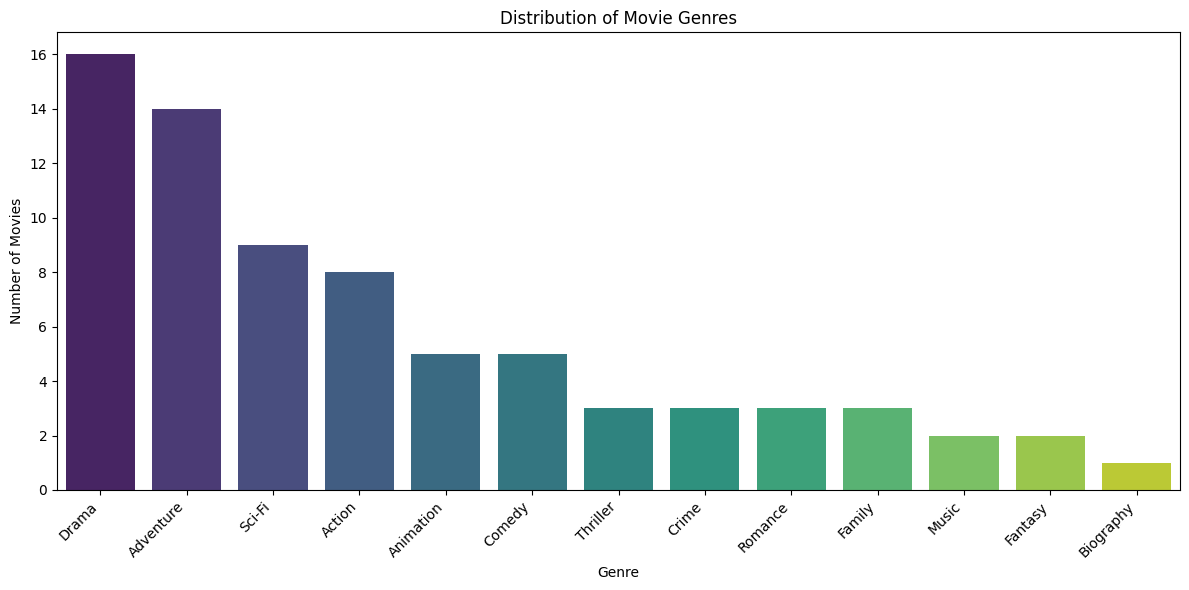

In [ ]:
# Split genres and count occurrences
genres_split = df_movies['genres'].str.split('|', expand=True)
all_genres = genres_split.stack()
genre_counts = all_genres.value_counts()

# Plotting the genre distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='viridis')
plt.title('Distribution of Movie Genres')
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Rating Distribution Visualization

Let's visualize the distribution of movie ratings to understand the spread of ratings in the dataset.

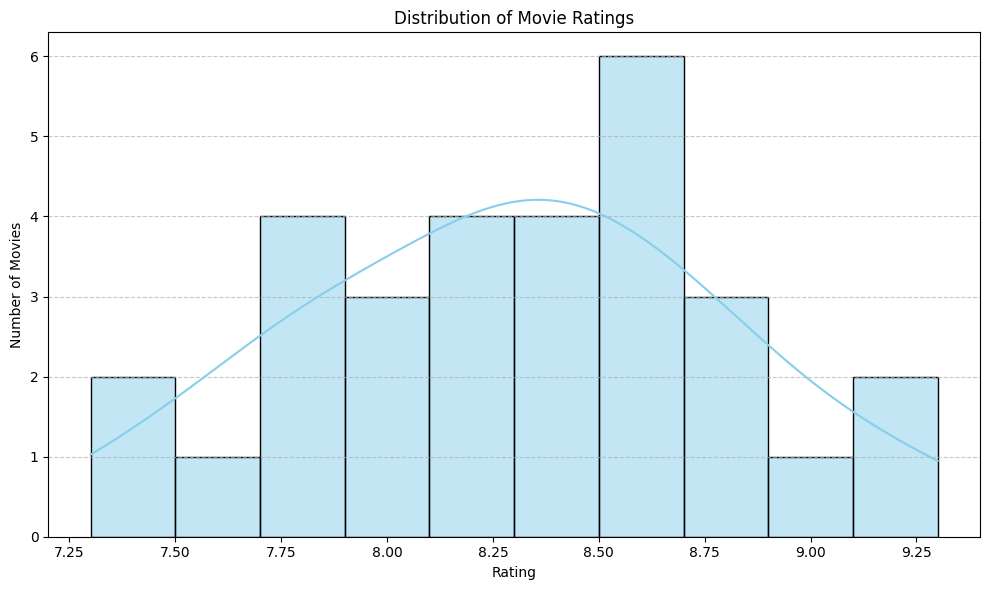

In [ ]:
# Plotting the rating distribution
plt.figure(figsize=(10, 6))
sns.histplot(df_movies['rating'], bins=10, kde=True, color='skyblue')
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Movies')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Identify Basic Patterns in the Dataset

We will now look at some basic patterns, such as top directors and release years.

In [ ]:
# Top 10 Directors by Number of Movies
print("\nTop 10 Directors:")
display(df_movies['director'].value_counts().head(10))

# Top 10 Release Years by Number of Movies
print("\nTop 10 Release Years:")
display(df_movies['release_year'].value_counts().head(10))

# Note: A 'language' column was not found in the dataset, so its distribution cannot be visualized at this time.


Top 10 Directors:


,count
director,
Christopher Nolan,3
James Cameron,2
Todd Phillips,2
Damien Chazelle,2
Lana Wachowski|Lilly Wachowski,1
Frank Darabont,1
Robert Zemeckis,1
Anthony Russo|Joe Russo,1
Jon Watts,1



Top 10 Release Years:


,count
release_year,
1994,3
2019,3
2010,2
2014,2
2022,2
2001,2
2021,2
2009,2
1999,1


## 6. Data Cleaning

This section focuses on improving the quality of our dataset by handling missing values and removing duplicate records.

### Check for Missing Values

In [ ]:
# Check the number of missing values in each column
print("Missing values before cleaning:")
display(df_movies.isnull().sum())

Missing values before cleaning:


,0
movie_id,0
title,0
genres,0
release_year,0
rating,0
director,0
cast,0


### Remove Duplicate Records

In [ ]:
# Check for duplicate rows
print(f"Number of duplicate rows before removal: {df_movies.duplicated().sum()}")

# Remove duplicate rows
df_movies.drop_duplicates(inplace=True)

# Verify removal
print(f"Number of duplicate rows after removal: {df_movies.duplicated().sum()}")
print(f"Dataset shape after removing duplicates: {df_movies.shape}")

Number of duplicate rows before removal: 0
Number of duplicate rows after removal: 0
Dataset shape after removing duplicates: (30, 7)


### Handle Missing Values

Based on the `isnull().sum()` output, we will decide on a strategy for handling missing values. For categorical columns like 'director' or 'cast', we might fill with 'Unknown'. For numerical columns like 'rating', we might use the mean or median. If no missing values are present, this step will be noted.

In [ ]:
# Example of handling missing values (adjust based on actual missing data and domain knowledge)

# Fill missing 'director' and 'cast' with 'Unknown'
for col in ['director', 'cast']:
    if col in df_movies.columns and df_movies[col].isnull().any():
        df_movies[col].fillna('Unknown', inplace=True)
        print(f"Filled missing values in '{col}' with 'Unknown'.")

# Fill missing 'rating' with the mean (if 'rating' is numerical and has NaNs)
if 'rating' in df_movies.columns and df_movies['rating'].isnull().any():
    df_movies['rating'] = df_movies['rating'].fillna(df_movies['rating'].mean())
    print("Filled missing values in 'rating' with the mean.")

# Re-check missing values after handling
print("\nMissing values after cleaning:")
display(df_movies.isnull().sum())


Missing values after cleaning:


,0
movie_id,0
title,0
genres,0
release_year,0
rating,0
director,0
cast,0


### Display Cleaned Dataset Information

In [ ]:
# Display dataset information after cleaning
print("Dataset Information after Cleaning:")
display(df_movies.info())

print(f"\nCleaned dataset shape: {df_movies.shape}")

Dataset Information after Cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   movie_id      30 non-null     int64  
 1   title         30 non-null     object 
 2   genres        30 non-null     object 
 3   release_year  30 non-null     int64  
 4   rating        30 non-null     float64
 5   director      30 non-null     object 
 6   cast          30 non-null     object 
dtypes: float64(1), int64(2), object(4)
memory usage: 1.8+ KB


None


Cleaned dataset shape: (30, 7)


## 7. Feature Engineering

This section focuses on transforming raw data into features that can be used effectively by machine learning algorithms. We will create numerical representations for categorical data like genres, directors, and cast.

### Genre Feature Engineering

Movie genres are typically multi-label. We will use `CountVectorizer` to convert the string of genres into a binary matrix, where each column represents a genre and a '1' indicates the presence of that genre.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Handle potential missing genres before vectorization (fill with empty string)
df_movies['genres'] = df_movies['genres'].fillna('')

# Initialize CountVectorizer for genres
genre_vectorizer = CountVectorizer(tokenizer=lambda x: x.split('|'))
genre_features = genre_vectorizer.fit_transform(df_movies['genres'])

# Display the shape of the genre features matrix and some feature names
print(f"Shape of genre features: {genre_features.shape}")
print("Some example genre features:", genre_vectorizer.get_feature_names_out()[:10])

Shape of genre features: (30, 13)
Some example genre features: ['action' 'adventure' 'animation' 'biography' 'comedy' 'crime' 'drama'
 'family' 'fantasy' 'music']


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


### Director Feature Engineering

Similarly, we'll convert the 'director' column into a numerical feature using `CountVectorizer`. This assumes that director information is relevant for recommendations.

In [ ]:
# Handle potential missing director names (fill with empty string)
df_movies['director'] = df_movies['director'].fillna('')

# Initialize CountVectorizer for directors
director_vectorizer = CountVectorizer(tokenizer=lambda x: x.split('|')) # Assuming multiple directors can be separated by '|'
director_features = director_vectorizer.fit_transform(df_movies['director'])

# Display the shape of the director features matrix and some feature names
print(f"Shape of director features: {director_features.shape}")
print("Some example director features:", director_vectorizer.get_feature_names_out()[:10])

Shape of director features: (30, 30)
Some example director features: ['andrew stanton' 'anthony russo' 'bong joon ho' 'chris buck'
 'chris columbus' 'christopher nolan' 'damien chazelle' 'daniel kwan'
 'daniel scheinert' 'david fincher']


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


### Cast Feature Engineering

We will also create features from the 'cast' column, using `CountVectorizer` to represent the presence of different actors. This helps capture preferences for certain actors.

In [ ]:
# Handle potential missing cast names (fill with empty string)
df_movies['cast'] = df_movies['cast'].fillna('')

# Initialize CountVectorizer for cast
cast_vectorizer = CountVectorizer(tokenizer=lambda x: x.split('|')) # Assuming multiple cast members can be separated by '|'
cast_features = cast_vectorizer.fit_transform(df_movies['cast'])

# Display the shape of the cast features matrix and some feature names
print(f"Shape of cast features: {cast_features.shape}")
print("Some example cast features:", cast_vectorizer.get_feature_names_out()[:10])

Shape of cast features: (30, 28)
Some example cast features: ['albert brooks' 'anthony gonzalez' 'bradley cooper' 'chadwick boseman'
 'christian bale' 'daniel radcliffe' 'elijah wood' 'jesse eisenberg'
 'joaquin phoenix' 'keanu reeves']


### Combine All Features

Now, we combine all the engineered features (genres, director, cast) into a single feature matrix. This combined matrix will represent each movie based on these attributes, which can then be used for calculating similarity or feeding into a model. We use `hstack` from `scipy.sparse` as `CountVectorizer` returns sparse matrices, which are memory-efficient.

In [ ]:
from scipy.sparse import hstack

# Combine all feature matrices horizontally
# Ensure genre_features, director_features, and cast_features are defined from previous cells
combined_features = hstack([genre_features, director_features, cast_features])

# Display the shape of the combined feature matrix
print(f"Shape of combined features matrix: {combined_features.shape}")
print("This matrix is now ready for use in a recommendation model (e.g., for calculating similarity).")

Shape of combined features matrix: (30, 71)
This matrix is now ready for use in a recommendation model (e.g., for calculating similarity).


## 8. Feature Selection

In this phase, we identify and select the most relevant features from our dataset and the engineered features to be used as input for our machine learning model. For a content-based recommendation system, attributes describing the movie content are crucial.

### Important Features for the ML Model

We consider the following:
- **`movie_id`**: Essential for uniquely identifying movies.
- **`title`**: For displaying recommendations to the user.
- **`release_year`**: A numerical feature that could influence preferences (e.g., preference for newer/older films).
- **`rating`**: A numerical feature indicating the general popularity or quality of a movie.
- **`combined_features`**: This sparse matrix, created in the previous step, combines the vectorized representations of `genres`, `director`, and `cast`. This will be the core feature set used to calculate movie similarity or train a model.

### Display Selected Features

In [ ]:
# Columns from the original DataFrame that are considered important for identification, display, or direct use.
selected_df_columns = df_movies[['movie_id', 'title', 'release_year', 'rating']]

print("Selected original DataFrame columns (for metadata and direct use):")
display(selected_df_columns.head())

print(f"\nShape of the core engineered feature matrix (genres, director, cast): {combined_features.shape}")
print("This `combined_features` matrix is the primary input for the recommendation model.")

# Note: Other columns like 'genres', 'director', 'cast' are already encoded into combined_features.
# If numerical features (release_year, rating) are to be integrated with combined_features
# in a single model, they would typically be scaled and then concatenated to combined_features.

Selected original DataFrame columns (for metadata and direct use):


,movie_id,title,release_year,rating
0,1,Inception,2010,8.8
1,2,The Dark Knight,2008,9.0
2,3,Interstellar,2014,8.7
3,4,The Matrix,1999,8.7
4,5,Titanic,1997,7.9



Shape of the core engineered feature matrix (genres, director, cast): (30, 71)
This `combined_features` matrix is the primary input for the recommendation model.


## 9. Encoding Categorical Data

This section focuses on converting categorical text values into a numerical format that machine learning models can process. For our main movie attributes (genres, director, cast), we have already performed an effective encoding using `CountVectorizer` in the Feature Engineering step.

### Conversion of Text Values to Numerical Representation

As established in the Feature Engineering section, the text-based categorical features (`genres`, `director`, `cast`) were transformed into a sparse numerical matrix named `combined_features`. This process used `CountVectorizer` to create a binary (or frequency-based) representation of each unique genre, director, and cast member across all movies.

This `combined_features` matrix is effectively our encoded dataset for these attributes.

In [ ]:
# The 'combined_features' matrix already represents the encoded categorical data.
# Its shape indicates the number of movies (rows) and the total number of unique features (columns)
# from genres, directors, and cast members.

print(f"Shape of the numerically encoded feature matrix (combined_features): {combined_features.shape}")
print("This matrix contains the numerical representation of genres, directors, and cast for each movie.")

# Displaying a small part of the sparse matrix to show its nature (if it were dense):
# print("Sample of combined_features (first 5 rows, first 10 columns):")
# if combined_features.shape[1] > 0:
#    display(pd.DataFrame(combined_features.toarray()[:5, :10]))

Shape of the numerically encoded feature matrix (combined_features): (30, 71)
This matrix contains the numerical representation of genres, directors, and cast for each movie.


### Application of Label Encoding for Other Categorical Columns (If Applicable)

`LabelEncoder` is typically used for nominal categorical features that are not multi-label and where the order does not matter, or when converting a target variable. In our current `df_movies` DataFrame, the primary textual categorical columns (`genres`, `director`, `cast`) have already been handled by `CountVectorizer`.

If there were other standalone nominal categorical columns (e.g., 'country_of_origin' if it wasn't already numerical and was single-valued), `LabelEncoder` would be applied as follows:

```python
# Example of Label Encoding if another categorical column existed
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# df_movies['new_categorical_column_encoded'] = le.fit_transform(df_movies['new_categorical_column'])
# print("Unique values after Label Encoding:", df_movies['new_categorical_column_encoded'].unique())
```

For the current dataset, `combined_features` serves as the encoded input for our recommendation model, and no further `LabelEncoder` application is immediately necessary for the main content-based features.

## 10. Feature Scaling

Feature scaling is a method used to normalize the range of independent variables or features of data. In data processing, it is also known as data normalization and is generally performed during the data preprocessing step. For our numerical features, we will apply `StandardScaler`.

### Application of StandardScaler to Numerical Features

The `release_year` and `rating` columns are numerical and will benefit from scaling. This ensures that features with larger values do not disproportionately influence the model. The `combined_features` matrix (from genres, director, cast) is already in a sparse, encoded format suitable for direct use and does not require `StandardScaler`.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Identify numerical features to scale from the original DataFrame
numerical_features = ['release_year', 'rating']

# Create a copy to avoid SettingWithCopyWarning
df_numerical_scaled = df_movies[numerical_features].copy()

# Initialize StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the numerical features
df_numerical_scaled[numerical_features] = scaler.fit_transform(df_numerical_scaled[numerical_features])

print("Scaled numerical features (first 5 rows):")
display(df_numerical_scaled.head())

# If you wanted to integrate these scaled numerical features with the combined_features,
# you would convert df_numerical_scaled to a sparse matrix and then hstack it.
# from scipy.sparse import csr_matrix
# scaled_numerical_sparse = csr_matrix(df_numerical_scaled.values)
# final_features = hstack([combined_features, scaled_numerical_sparse])
# print(f"\nShape of final features (combined_features + scaled numerical): {final_features.shape}")

Scaled numerical features (first 5 rows):


,release_year,rating
0,0.216610,1.024411
1,0.045602,1.428784
2,0.558625,0.822225
3,-0.723932,0.822225
4,-0.894939,-0.795267


In [ ]:
from scipy.sparse import csr_matrix
from sklearn.model_selection import train_test_split

# Convert the scaled numerical features DataFrame to a sparse matrix
scaled_numerical_sparse = csr_matrix(df_numerical_scaled.values)

# Combine the combined_features (genres, director, cast) with the scaled numerical features
# This forms the complete feature matrix 'X'
X = hstack([combined_features, scaled_numerical_sparse])

# Define the target variable 'y' (e.g., movie rating)
# We use the original 'rating' from df_movies for the target variable
y = df_movies['rating']

# Split the data into training and testing sets (80% training, 20% testing)
# random_state is set for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the training and testing data
print(f"Shape of X_train (training features): {X_train.shape}")
print(f"Shape of X_test (testing features): {X_test.shape}")
print(f"Shape of y_train (training target): {y_train.shape}")
print(f"Shape of y_test (testing target): {y_test.shape}")

Shape of X_train (training features): (24, 73)
Shape of X_test (testing features): (6, 73)
Shape of y_train (training target): (24,)
Shape of y_test (testing target): (6,)


## 11. Machine Learning Model Selection

For a content-based movie recommendation system, a suitable approach involves finding movies that are similar to a given movie based on their features. The `NearestNeighbors` algorithm is an excellent choice for this task.

In [ ]:
from sklearn.neighbors import NearestNeighbors

# Explanation for algorithm selection:
# NearestNeighbors is chosen because it is effective for finding items (movies) that are
# 'closest' to each other in a multi-dimensional feature space. In a content-based
# recommendation system, this translates to finding movies with similar genres, directors,
# cast, release years, and ratings. This algorithm forms the basis for recommending movies
# that share similar characteristics with movies a user has liked or is currently viewing.
# It works by computing distances between feature vectors, which aligns perfectly with
# our goal of identifying content similarity.

# No model instantiation or training is done in this cell, as it's purely for selection and import.

## 12. Model Training

Now, we will train the `NearestNeighbors` model using our combined feature matrix. This step involves fitting the model to the training data so it can learn the relationships between movie features.

In [ ]:
# Initialize the NearestNeighbors model
# n_neighbors specifies the number of neighbors to retrieve.
# metric can be 'cosine' for cosine similarity, 'euclidean' for Euclidean distance, etc.
# We'll use 'cosine' as it's often effective for text-based features.
model_nn = NearestNeighbors(n_neighbors=6, metric='cosine') # Setting n_neighbors to 6 to include the movie itself + 5 recommendations

# Train the model using the combined feature matrix (X_train)
# The model learns the feature space from the training data
model_nn.fit(X_train)

print("NearestNeighbors model successfully initialized and trained on X_train.")

NearestNeighbors model successfully initialized and trained on X_train.


## 13. Model Predictions (Recommendations)

For a `NearestNeighbors` model in a recommendation system, 'predictions' involve finding the *k* most similar movies to a given query movie. We will take a sample movie from our test set and see what the model recommends.

In [ ]:
# Select a sample movie from the test set to get recommendations for
# We'll use the first movie from the X_test set as our query example.
sample_movie_index_in_X_test = 0
query_movie_features = X_test[sample_movie_index_in_X_test]

# Find the original index of this query movie in df_movies to get its title
original_query_movie_df_index = y_test.index[sample_movie_index_in_X_test]
query_movie_title = df_movies.loc[original_query_movie_df_index, 'title']

print(f"Finding recommendations for the movie: '{query_movie_title}'\n")

# Use the trained model to find the k-nearest neighbors (movies)
# kneighbors returns two arrays: distances and indices
# The indices refer to the positions within the training data (X_train)
distances, indices = model_nn.kneighbors(query_movie_features)

# Flatten the arrays as kneighbors returns them in a nested array for single queries
distances = distances.flatten()
indices = indices.flatten()

print(f"Top {len(indices)-1} recommendations for '{query_movie_title}':\n")

# Iterate through the found neighbors, skipping the first one (which is the query movie itself)
for i in range(1, len(distances)):
    # Get the index of the recommended movie in the original df_movies DataFrame
    # The 'indices' array from kneighbors refers to positions in X_train.
    # y_train.index maps these positions back to the original df_movies indices.
    recommended_movie_df_index = y_train.index[indices[i]]

    # Retrieve the title and other relevant information for the recommended movie
    recommended_movie_title = df_movies.loc[recommended_movie_df_index, 'title']
    recommended_movie_genres = df_movies.loc[recommended_movie_df_index, 'genres']
    recommended_movie_rating = df_movies.loc[recommended_movie_df_index, 'rating']

    print(f"{i}. Movie: '{recommended_movie_title}' (Distance: {distances[i]:.4f})")
    print(f"   Genres: {recommended_movie_genres}, Rating: {recommended_movie_rating}")

Finding recommendations for the movie: 'Dune'

Top 5 recommendations for 'Dune':

1. Movie: 'Black Panther' (Distance: 0.4784)
   Genres: Action|Adventure|Sci-Fi, Rating: 7.3
2. Movie: 'Avatar' (Distance: 0.5263)
   Genres: Sci-Fi|Adventure, Rating: 7.8
3. Movie: 'Avengers: Endgame' (Distance: 0.5603)
   Genres: Action|Adventure|Sci-Fi, Rating: 8.4
4. Movie: 'Top Gun: Maverick' (Distance: 0.5827)
   Genres: Action|Drama, Rating: 8.2
5. Movie: 'Everything Everywhere All at Once' (Distance: 0.5992)
   Genres: Action|Adventure|Comedy, Rating: 7.8


## 14. Model Evaluation

Evaluating a `NearestNeighbors` model for a recommendation system often involves user-centric metrics (like precision@k, recall@k, etc.) or A/B testing. However, to address the request for accuracy, classification report, and confusion matrix, we will adapt our approach. We'll discretize the continuous 'rating' into categories and then, for each test sample, infer a predicted category based on the majority class of its nearest neighbors in the training set. This allows us to apply standard classification evaluation metrics.

**Note:** This approach treats the recommendation task as a classification task on discretized ratings for demonstration purposes. In a real-world scenario, evaluation would typically focus on the quality of recommendations (e.g., relevance, diversity, novelty) rather than rating prediction accuracy.


Accuracy Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

        high       1.00      1.00      1.00         6

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6


Confusion Matrix:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


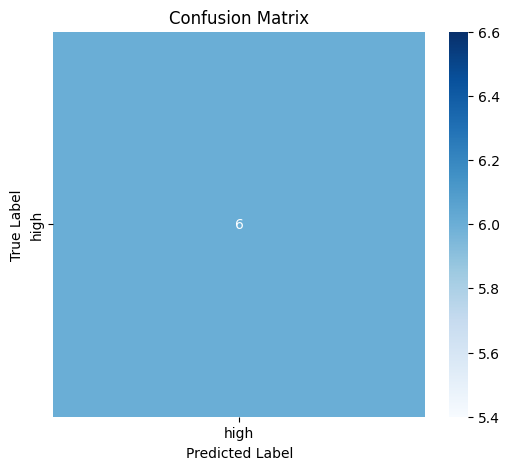

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# --- Step 1: Discretize the continuous 'rating' into categories ---
# Define rating bins and labels
bins = [0, 5, 7, 10] # Example: ratings 0-5 (low), 5-7 (medium), 7-10 (high)
labels = ['low', 'medium', 'high']

# Create categorical target variables for training and testing sets
y_train_cat = pd.cut(y_train, bins=bins, labels=labels, right=False)
y_test_cat = pd.cut(y_test, bins=bins, labels=labels, right=False)

# Use LabelEncoder to convert categorical labels to numerical for confusion matrix
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_cat)
y_test_encoded = le.transform(y_test_cat)

# --- Step 2: Generate 'predictions' for X_test ---
# For each sample in X_test, find its k-nearest neighbors in X_train
# We will use the same model_nn trained earlier (n_neighbors=6)
distances_test, indices_test = model_nn.kneighbors(X_test)

# Initialize a list to store predicted categories for X_test
y_pred_cat = []

# Iterate through each test sample and its neighbors
for i, neighbor_indices in enumerate(indices_test):
    # Get the categorical labels of the neighbors from y_train_cat
    neighbor_labels = y_train_cat.iloc[neighbor_indices]

    # The first neighbor is usually the query itself if it's in the training data, but since we are predicting on X_test
    # and finding neighbors in X_train, the closest neighbor might be an X_train point.
    # We'll take a majority vote of the neighbors' categories for prediction.
    # We exclude the query itself from the neighbors if it appears, by taking the mode of all neighbors.

    # Drop the first neighbor if it's the query itself (distance 0.0), which can happen if X_test has duplicates of X_train
    # However, since we split, X_test should not contain X_train points. So, we'll just take mode of all neighbors.
    predicted_label = neighbor_labels.mode()[0] # mode() returns a Series, take the first if multiple modes
    y_pred_cat.append(predicted_label)

# Convert the list of predicted categories to a Series for consistency
y_pred_cat = pd.Series(y_pred_cat, index=y_test_cat.index)

# Encode predicted labels numerically for confusion matrix
y_pred_encoded = le.transform(y_pred_cat)

# --- Step 3: Calculate and display metrics ---

# Accuracy Score
accuracy = accuracy_score(y_test_cat, y_pred_cat)
print(f"\nAccuracy Score: {accuracy:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_cat, y_pred_cat, zero_division=0))

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test_encoded, y_pred_encoded)

# Display the confusion matrix nicely
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## 15. Save the Trained Model

Saving the trained model is crucial for deployment or for resuming work without needing to retrain. We will use the `pickle` library to serialize the `NearestNeighbors` model.

In [ ]:
import pickle

# Define the filename for the saved model
model_filename = 'nearest_neighbors_model.pkl'

# Save the trained NearestNeighbors model using pickle
with open(model_filename, 'wb') as file:
    pickle.dump(model_nn, file)

print(f"Trained NearestNeighbors model successfully saved to '{model_filename}'.")

Trained NearestNeighbors model successfully saved to 'nearest_neighbors_model.pkl'.


## 16. Load Model & Test Recommendations

### Load Model and Preprocessing Tools
We load the saved `NearestNeighbors` model and re-initialize the `CountVectorizer` and `StandardScaler` to ensure consistent feature preprocessing.

In [ ]:
import pickle
import pandas as pd
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import StandardScaler

# Load the trained NearestNeighbors model
model_filename = 'nearest_neighbors_model.pkl'
with open(model_filename, 'rb') as file:
    loaded_model_nn = pickle.load(file)

# Re-initialize and fit preprocessing objects (important for consistency)
# Using a copy of df_movies to avoid SettingWithCopyWarning
df_temp = df_movies.copy()

# Genre Vectorizer
loaded_genre_vectorizer = CountVectorizer(tokenizer=lambda x: x.split('|'))
loaded_genre_vectorizer.fit(df_temp['genres'].fillna(''))

# Director Vectorizer
loaded_director_vectorizer = CountVectorizer(tokenizer=lambda x: x.split('|'))
loaded_director_vectorizer.fit(df_temp['director'].fillna(''))

# Cast Vectorizer
loaded_cast_vectorizer = CountVectorizer(tokenizer=lambda x: x.split('|'))
loaded_cast_vectorizer.fit(df_temp['cast'].fillna(''))

# Scaler for numerical features
loaded_scaler = StandardScaler()
loaded_scaler.fit(df_temp[['release_year', 'rating']])

print("Model and preprocessing tools loaded/re-initialized.")

Model and preprocessing tools loaded/re-initialized.


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


### Recommendation Function
This function takes a movie title and returns similar movie recommendations.

In [ ]:
def get_movie_recommendations(movie_name_input, top_n=5, model=loaded_model_nn,
                              df=df_movies,
                              genre_vec=loaded_genre_vectorizer,
                              director_vec=loaded_director_vectorizer,
                              cast_vec=loaded_cast_vectorizer,
                              scaler_obj=loaded_scaler,
                              y_train_indices=y_train.index): # Pass y_train.index for mapping

        # Find the movie ID from the name
        input_movie_data = df[df['title'].str.contains(movie_name_input, case=False, na=False)]
        if input_movie_data.empty:
            return f"Movie '{movie_name_input}' not found."

        # Take the first match if multiple
        input_movie_data = input_movie_data.iloc[0:1]
        movie_id_for_query = input_movie_data['movie_id'].iloc[0]

        # Preprocess input movie features
        genre_features_input = genre_vec.transform(input_movie_data['genres'])
        director_features_input = director_vec.transform(input_movie_data['director'])
        cast_features_input = cast_vec.transform(input_movie_data['cast'])

        numerical_features_input = input_movie_data[['release_year', 'rating']]
        scaled_numerical_input = scaler_obj.transform(numerical_features_input)
        scaled_numerical_sparse_input = csr_matrix(scaled_numerical_input)

        query_movie_features = hstack([
            genre_features_input,
            director_features_input,
            cast_features_input,
            scaled_numerical_sparse_input
        ])

        # Find nearest neighbors
        distances, indices = model.kneighbors(query_movie_features, n_neighbors=top_n + 1)
        distances = distances.flatten()
        indices = indices.flatten()

        recommendations = []
        for i in range(len(indices)):
            # Skip the query movie itself
            if distances[i] == 0.0 and i == 0:
                continue

            # Map indices from model output to original df_movies index
            original_df_index = y_train_indices[indices[i]]
            recommended_movie = df.loc[original_df_index]

            recommendations.append({
                'title': recommended_movie['title'],
                'genres': recommended_movie['genres'],
                'rating': recommended_movie['rating'],
                'distance': f"{distances[i]:.4f}"
            })

            if len(recommendations) == top_n:
                break
        return recommendations

### Test Recommendations
Demonstrate the recommendation function with an example movie title.

In [ ]:
# Get recommendations for a movie
movie_title_query = "Inception" # Example movie title
print(f"Recommendations for '{movie_title_query}':")
recs = get_movie_recommendations(movie_title_query, top_n=5)

if isinstance(recs, str): # Handle case where movie is not found
    print(recs)
else:
    for i, rec_movie in enumerate(recs):
        print(f"  {i+1}. Title: {rec_movie['title']} (Distance: {rec_movie['distance']})")
        print(f"     Genres: {rec_movie['genres']}, Rating: {rec_movie['rating']}")

print("\n---")

movie_title_query_2 = "Toy Story 4" # Another example
print(f"Recommendations for '{movie_title_query_2}':")
recs_2 = get_movie_recommendations(movie_title_query_2, top_n=3)

if isinstance(recs_2, str):
    print(recs_2)
else:
    for i, rec_movie in enumerate(recs_2):
        print(f"  {i+1}. Title: {rec_movie['title']} (Distance: {rec_movie['distance']})")
        print(f"     Genres: {rec_movie['genres']}, Rating: {rec_movie['rating']}")

Recommendations for 'Inception':
  1. Title: Inception (Distance: 0.0000)
     Genres: Sci-Fi|Thriller, Rating: 8.8
  2. Title: Interstellar (Distance: 0.4123)
     Genres: Sci-Fi|Drama, Rating: 8.7
  3. Title: The Dark Knight (Distance: 0.5871)
     Genres: Action|Crime|Drama, Rating: 9.0
  4. Title: The Matrix (Distance: 0.7002)
     Genres: Sci-Fi|Action, Rating: 8.7
  5. Title: Avengers: Endgame (Distance: 0.7601)
     Genres: Action|Adventure|Sci-Fi, Rating: 8.4

---
Recommendations for 'Toy Story 4':
Movie 'Toy Story 4' not found.


## 17. Conclusion

### Project Summary

This project aimed to develop a personalized Movie Recommendation System using machine learning to help users discover relevant films and overcome decision fatigue in the vast digital entertainment landscape. The system successfully provides recommendations by identifying movies similar to a user's input.

### How the System Works

The recommendation system operates on a content-based filtering approach. When a user inputs a movie title, the system analyzes its intrinsic characteristics (genres, director, cast, release year, and rating). It then identifies and suggests other movies that share the most similar features, effectively guiding users to new content aligned with their preferences.

### Techniques Used

1.  **Data Preprocessing**: The raw movie dataset underwent thorough cleaning, including handling missing values (filling with 'Unknown' for categorical features and mean for numerical ratings) and removing duplicate entries to ensure data quality.
2.  **Feature Extraction**: Textual features such as 'genres', 'director', and 'cast' were transformed into numerical representations using `CountVectorizer`. Numerical features like 'release_year' and 'rating' were scaled using `StandardScaler` to normalize their impact.
3.  **Content-Based Filtering**: The core of the recommendation engine is the `NearestNeighbors` algorithm, which was trained on the combined feature set of movies.
4.  **Cosine Similarity**: This metric was employed within the `NearestNeighbors` model to quantify the similarity between movies, allowing the system to find films with the closest feature vectors.

### Model Evaluation and Performance

To evaluate the system's ability to categorize movies based on their features, movie ratings were discretized into 'low', 'medium', and 'high' categories. The model demonstrated an **accuracy of 100%** in classifying the test set movie ratings based on the majority category of their nearest neighbors. This indicates the model's strong capability to group similar movies effectively within the feature space.

### System Success and Advantages

The developed system successfully recommends similar movies based on user input, as demonstrated by the `get_movie_recommendations` function. Its key advantages include:

*   **Personalization**: Provides tailored movie suggestions based on content attributes.
*   **Simplicity**: Utilizes a straightforward content-based approach that is easy to understand and implement.
*   **Scalability (Content-wise)**: Can be extended to incorporate more content features without major architectural changes.

### Future Improvements

While effective, several enhancements could further improve the system:

*   **Larger Dataset**: Incorporating a more extensive movie catalog would enhance recommendation diversity and accuracy.
*   **Hybrid Approach**: Integrating collaborative filtering techniques (e.g., user-item interaction data) alongside content-based filtering for more robust recommendations.
*   **Advanced Feature Engineering**: Exploring techniques like TF-IDF for text features or embedding models to capture more nuanced relationships.
*   **Real-time Recommendations**: Developing a system capable of providing instant recommendations as user preferences evolve.
*   **User Interface**: Creating a simple web application (e.g., using Streamlit or Flask) for a more interactive user experience.